In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

project_root = os.path.dirname(os.getcwd())
data_dir = os.path.join(project_root, 'data')
charts_dir = os.path.join(project_root, 'outputs', 'charts')

os.makedirs(data_dir, exist_ok=True)
os.makedirs(charts_dir, exist_ok=True)

print("Project root:", project_root)
print("Data dir:", data_dir)
print("Charts dir:", charts_dir)

df = pd.read_csv('C:\\Users\\Nikhil\\Downloads\\HHS_Unaccompanied_Alien_Children_Program.csv')
print("Raw shape:", df.shape)
df.head()

Project root: C:\Users\Nikhil\OneDrive\Desktop\Care_Transition_Analytics
Data dir: C:\Users\Nikhil\OneDrive\Desktop\Care_Transition_Analytics\data
Charts dir: C:\Users\Nikhil\OneDrive\Desktop\Care_Transition_Analytics\outputs\charts
Raw shape: (1170, 6)


,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [2]:
df = df.dropna(how='all').reset_index(drop=True)
print("After dropping empty rows:", df.shape)

After dropping empty rows: (720, 6)


In [3]:
df.columns = [
    'date',
    'cbp_apprehended',
    'cbp_custody',
    'cbp_transferred_out',
    'hhs_care',
    'hhs_discharged'
]
df.head()

,date,cbp_apprehended,cbp_custody,cbp_transferred_out,hhs_care,hhs_discharged
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [4]:
df['hhs_care'] = df['hhs_care'].astype(str).str.replace(',', '', regex=False)
df['hhs_care'] = pd.to_numeric(df['hhs_care'], errors='coerce')

df['date'] = pd.to_datetime(df['date'], format='%B %d, %Y', errors='coerce')

print("Unparsed dates:", df['date'].isna().sum())

Unparsed dates: 0


In [5]:
df = df.sort_values('date').reset_index(drop=True)

print(df.isnull().sum())
df.head()

date                   0
cbp_apprehended        0
cbp_custody            0
cbp_transferred_out    0
hhs_care               0
hhs_discharged         0
dtype: int64


,date,cbp_apprehended,cbp_custody,cbp_transferred_out,hhs_care,hhs_discharged
0,2023-01-12,33.0,53.0,34.0,6566,436.0
1,2023-01-22,32.0,49.0,39.0,7122,227.0
2,2023-01-23,32.0,50.0,39.0,7280,181.0
3,2023-01-24,47.0,42.0,47.0,7433,175.0
4,2023-01-25,20.0,22.0,41.0,7538,180.0


In [6]:
df['date_diff'] = df['date'].diff().dt.days
print(df['date_diff'].value_counts().head(10))

date_diff
1.0     558
3.0     122
4.0      23
2.0      10
5.0       3
10.0      1
6.0       1
7.0       1
Name: count, dtype: int64


In [7]:
df.describe()

,date,cbp_apprehended,cbp_custody,cbp_transferred_out,hhs_care,hhs_discharged,date_diff
count,720,720.000000,720.000000,720.000000,720.000000,720.000000,719.000000
mean,2024-07-06 05:29:59.999999744,93.523611,171.494444,128.668056,6061.275000,173.406944,1.493741
min,2023-01-12 00:00:00,0.000000,7.000000,0.000000,1972.000000,0.000000,1.000000
25%,2023-10-16 18:00:00,12.000000,36.000000,14.000000,2467.750000,19.750000,1.000000
50%,2024-07-05 12:00:00,99.000000,193.000000,157.000000,6406.500000,181.000000,1.000000
75%,2025-03-25 06:00:00,147.250000,263.250000,199.250000,8010.250000,267.000000,1.000000
max,2025-12-21 00:00:00,333.000000,531.000000,440.000000,11516.000000,505.000000,10.000000
std,NaN,72.646625,126.354965,97.322012,2833.070109,125.702841,1.001198


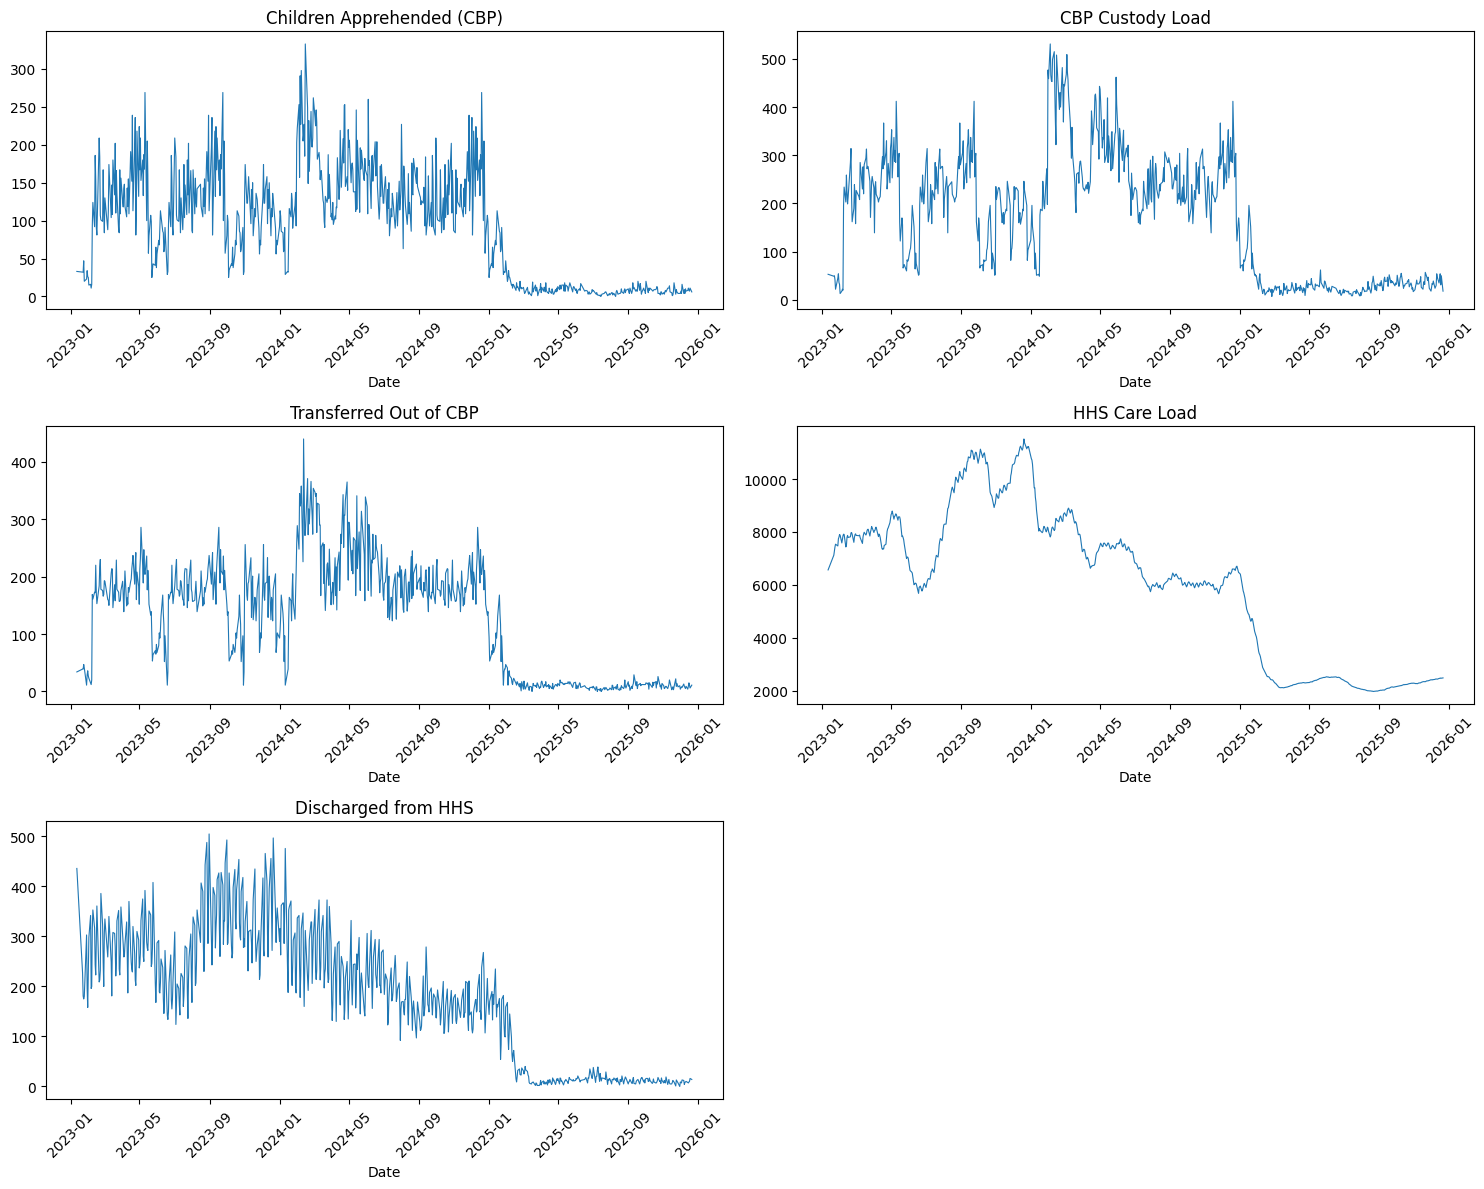

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
cols = ['cbp_apprehended', 'cbp_custody', 'cbp_transferred_out', 'hhs_care', 'hhs_discharged']
titles = ['Children Apprehended (CBP)', 'CBP Custody Load', 'Transferred Out of CBP', 
          'HHS Care Load', 'Discharged from HHS']

for i, (col, title) in enumerate(zip(cols, titles)):
    ax = axes[i // 2, i % 2]
    ax.plot(df['date'], df[col], linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel('Date')
    ax.tick_params(axis='x', rotation=45)

axes[2, 1].axis('off')
plt.tight_layout()
plt.savefig(os.path.join(charts_dir, 'raw_metrics_timeseries.png'), dpi=150)
plt.show()

In [9]:
df['transfer_efficiency_ratio'] = df['cbp_transferred_out'] / df['cbp_custody']

df['discharge_effectiveness'] = df['hhs_discharged'] / df['hhs_care']

df['total_exits'] = df['cbp_transferred_out'] + df['hhs_discharged']
df['total_entries'] = df['cbp_apprehended']
df['pipeline_throughput'] = df['total_exits'] / df['total_entries']

df[['date', 'transfer_efficiency_ratio', 'discharge_effectiveness', 'pipeline_throughput']].describe()

D:\Anaconda\envs\tfgpu\lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,date,transfer_efficiency_ratio,discharge_effectiveness,pipeline_throughput
count,720,720.000000,720.000000,720.000000
mean,2024-07-06 05:29:59.999999744,0.691018,0.023737,inf
min,2023-01-12 00:00:00,0.000000,0.000000,0.733333
25%,2023-10-16 18:00:00,0.500000,0.008616,2.436611
50%,2024-07-05 12:00:00,0.704449,0.026297,3.263958
75%,2025-03-25 06:00:00,0.846429,0.032939,4.653669
max,2025-12-21 00:00:00,2.300000,0.066403,inf
std,NaN,0.309811,0.013310,NaN


In [10]:
kpi_cols = ['transfer_efficiency_ratio', 'discharge_effectiveness', 'pipeline_throughput']
df[kpi_cols] = df[kpi_cols].replace([np.inf, -np.inf], np.nan)

print("NaN/Inf counts after cleanup:")
print(df[kpi_cols].isna().sum())

NaN/Inf counts after cleanup:
transfer_efficiency_ratio    0
discharge_effectiveness      0
pipeline_throughput          2
dtype: int64


In [11]:
inf_rows = df[df['pipeline_throughput'].isin([np.inf, -np.inf])]
print(inf_rows[['date', 'cbp_apprehended', 'cbp_transferred_out', 'hhs_discharged']])

Empty DataFrame
Columns: [date, cbp_apprehended, cbp_transferred_out, hhs_discharged]
Index: []


In [12]:
df.loc[df['total_entries'] == 0, 'pipeline_throughput'] = np.nan

In [13]:
df['month'] = df['date'].dt.to_period('M')
monthly_avg = df.groupby('month')['hhs_care'].mean()
print(monthly_avg)

month
2023-01     7369.625000
2023-02     7795.789474
2023-03     7945.368421
2023-04     7842.666667
2023-05     8187.136364
2023-06     6136.450000
2023-07     6828.095238
2023-08     9347.900000
2023-09    10701.315789
2023-10    10205.318182
2023-11     9726.100000
2023-12    11068.631579
2024-01     8851.045455
2024-02     8325.200000
2024-03     8382.666667
2024-04     7027.136364
2024-05     7490.285714
2024-06     7407.523810
2024-07     6286.333333
2024-08     6004.263158
2024-09     6213.409091
2024-10     6032.857143
2024-11     5914.684211
2024-12     6418.681818
2025-01     4991.090909
2025-02     2781.526316
2025-03     2164.454545
2025-04     2273.130435
2025-05     2406.944444
2025-06     2492.411765
2025-07     2187.190476
2025-08     2001.300000
2025-09     2082.227273
2025-10     2231.047619
2025-11     2325.894737
2025-12     2445.266667
Freq: M, Name: hhs_care, dtype: float64


In [14]:
df['regime'] = np.where(df['date'] < '2025-02-01', 'pre_2025_shift', 'post_2025_shift')

df.groupby('regime').agg(
    avg_hhs_care=('hhs_care', 'mean'),
    avg_transfer_efficiency=('transfer_efficiency_ratio', 'mean'),
    avg_discharge_effectiveness=('discharge_effectiveness', 'mean'),
    days=('date', 'count')
)

,avg_hhs_care,avg_transfer_efficiency,avg_discharge_effectiveness,days
regime,,,,
post_2025_shift,2294.626728,0.414124,0.006802,217
pre_2025_shift,7686.250497,0.810473,0.031043,503


In [15]:
df['net_flow'] = df['cbp_apprehended'] - df['hhs_discharged']

df['cumulative_backlog'] = df.groupby('regime')['net_flow'].cumsum()

df['backlog_accumulation_rate'] = df['net_flow'].rolling(window=7, min_periods=1).mean()

In [16]:
rolling_mean = df['discharge_effectiveness'].rolling(window=14, min_periods=5).mean()
rolling_std = df['discharge_effectiveness'].rolling(window=14, min_periods=5).std()

df['outcome_stability_score'] = rolling_std / rolling_mean  
df['outcome_stability_score_inverted'] = 1 / (1 + df['outcome_stability_score'])

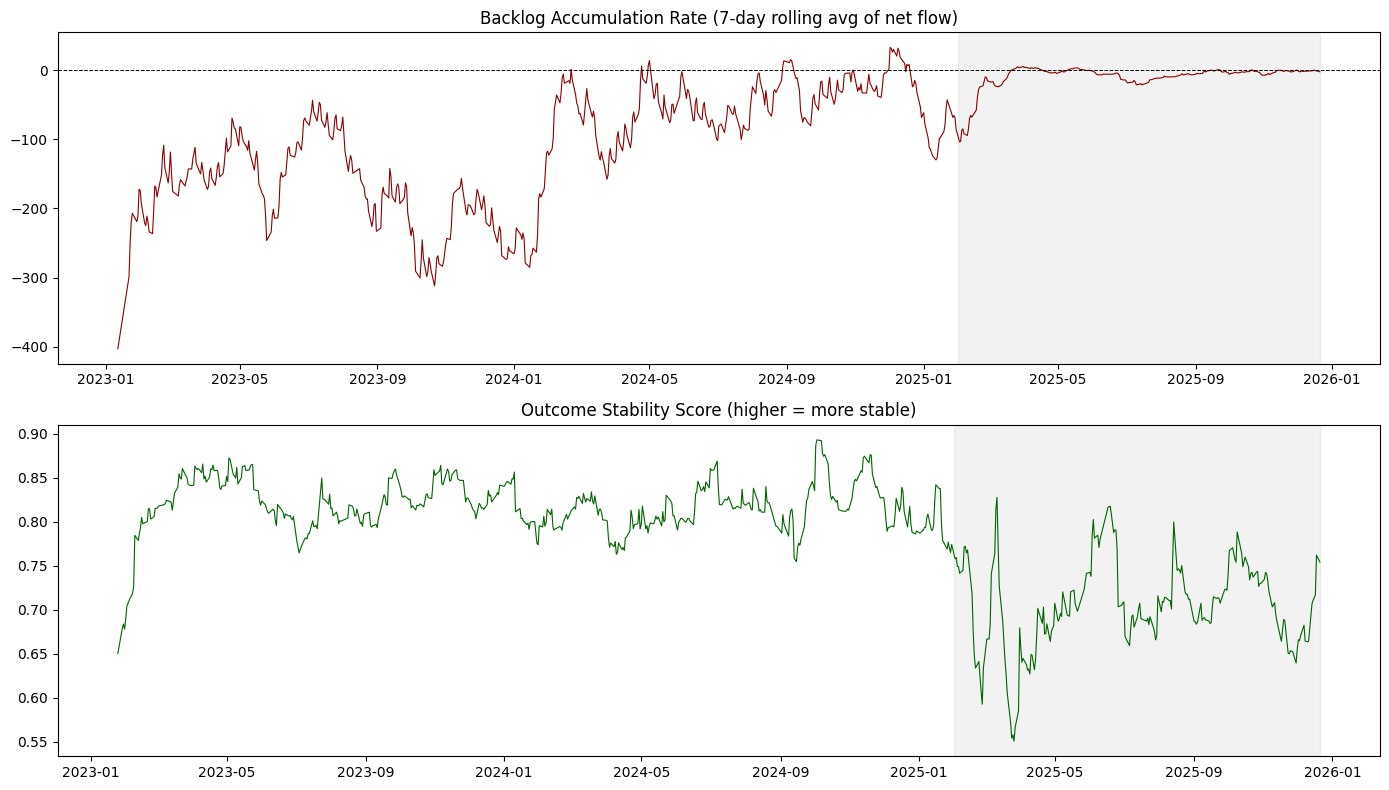

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df['date'], df['backlog_accumulation_rate'], color='darkred', linewidth=0.8)
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.7)
axes[0].set_title('Backlog Accumulation Rate (7-day rolling avg of net flow)')
axes[0].axvspan(pd.Timestamp('2025-02-01'), df['date'].max(), alpha=0.1, color='gray')

axes[1].plot(df['date'], df['outcome_stability_score_inverted'], color='darkgreen', linewidth=0.8)
axes[1].set_title('Outcome Stability Score (higher = more stable)')
axes[1].axvspan(pd.Timestamp('2025-02-01'), df['date'].max(), alpha=0.1, color='gray')

plt.tight_layout()
plt.savefig(os.path.join(charts_dir, 'backlog_stability_kpis.png'), dpi=150)
plt.show()

In [18]:
df['day_of_week'] = df['date'].dt.day_name()
df['is_weekend'] = df['date'].dt.dayofweek >= 5

weekday_summary = df.groupby('day_of_week').agg(
    avg_transfer_efficiency=('transfer_efficiency_ratio', 'mean'),
    avg_discharge_effectiveness=('discharge_effectiveness', 'mean'),
    avg_cases_processed=('hhs_discharged', 'mean')
).reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

print(weekday_summary)

             avg_transfer_efficiency  avg_discharge_effectiveness  \
day_of_week                                                         
Monday                      0.660516                     0.021711   
Tuesday                     0.670485                     0.018705   
Wednesday                   0.692006                     0.022596   
Thursday                    0.732629                     0.027853   
Friday                      0.711818                     0.024037   
Saturday                         NaN                          NaN   
Sunday                      0.700083                     0.028396   

             avg_cases_processed  
day_of_week                       
Monday                157.558621  
Tuesday               136.114094  
Wednesday             166.013605  
Thursday              205.687075  
Friday                144.000000  
Saturday                     NaN  
Sunday                206.138462  


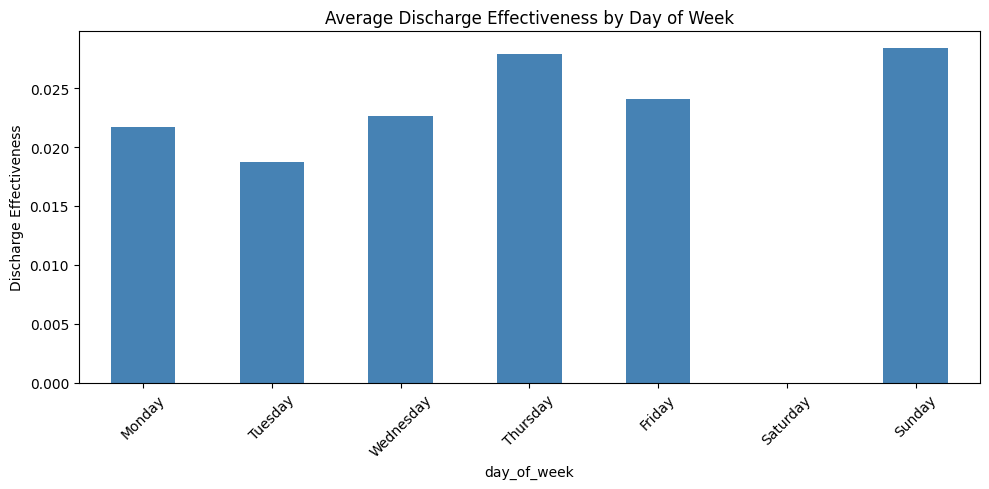

In [19]:
fig, ax = plt.subplots(figsize=(10,5))
weekday_summary['avg_discharge_effectiveness'].plot(kind='bar', color='steelblue', ax=ax)
ax.set_title('Average Discharge Effectiveness by Day of Week')
ax.set_ylabel('Discharge Effectiveness')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(charts_dir, 'weekday_pattern.png'), dpi=150)
plt.show()

In [20]:
df['is_backlog_day'] = df['net_flow'] > 0

df['streak_id'] = (df['is_backlog_day'] != df['is_backlog_day'].shift()).cumsum()
streaks = df[df['is_backlog_day']].groupby('streak_id').agg(
    start_date=('date', 'first'),
    end_date=('date', 'last'),
    length=('date', 'count'),
    total_excess=('net_flow', 'sum')
)

bottleneck_periods = streaks[streaks['length'] >= 5].sort_values('length', ascending=False)
print(bottleneck_periods)

          start_date   end_date  length  total_excess
streak_id                                            
106       2025-03-30 2025-04-03       5          22.0


In [21]:
monthly_kpis = df.groupby('month').agg(
    avg_transfer_efficiency=('transfer_efficiency_ratio', 'mean'),
    avg_discharge_effectiveness=('discharge_effectiveness', 'mean'),
    avg_pipeline_throughput=('pipeline_throughput', 'mean'),
    avg_backlog_rate=('backlog_accumulation_rate', 'mean'),
    avg_stability=('outcome_stability_score_inverted', 'mean'),
    total_discharged=('hhs_discharged', 'sum'),
    total_apprehended=('cbp_apprehended', 'sum')
).reset_index()

monthly_kpis['month'] = monthly_kpis['month'].astype(str)
print(monthly_kpis.tail(10))

      month  avg_transfer_efficiency  avg_discharge_effectiveness  \
26  2025-03                 0.428996                     0.006403   
27  2025-04                 0.430577                     0.003878   
28  2025-05                 0.446005                     0.004734   
29  2025-06                 0.440585                     0.006652   
30  2025-07                 0.305450                     0.008553   
31  2025-08                 0.310891                     0.006349   
32  2025-09                 0.343416                     0.005168   
33  2025-10                 0.394239                     0.005175   
34  2025-11                 0.286217                     0.003614   
35  2025-12                 0.256301                     0.003923   

    avg_pipeline_throughput  avg_backlog_rate  avg_stability  \
26                 4.575719         -9.220779       0.664469   
27                 2.826329          0.378882       0.661810   
28                 2.270587          0.230159   

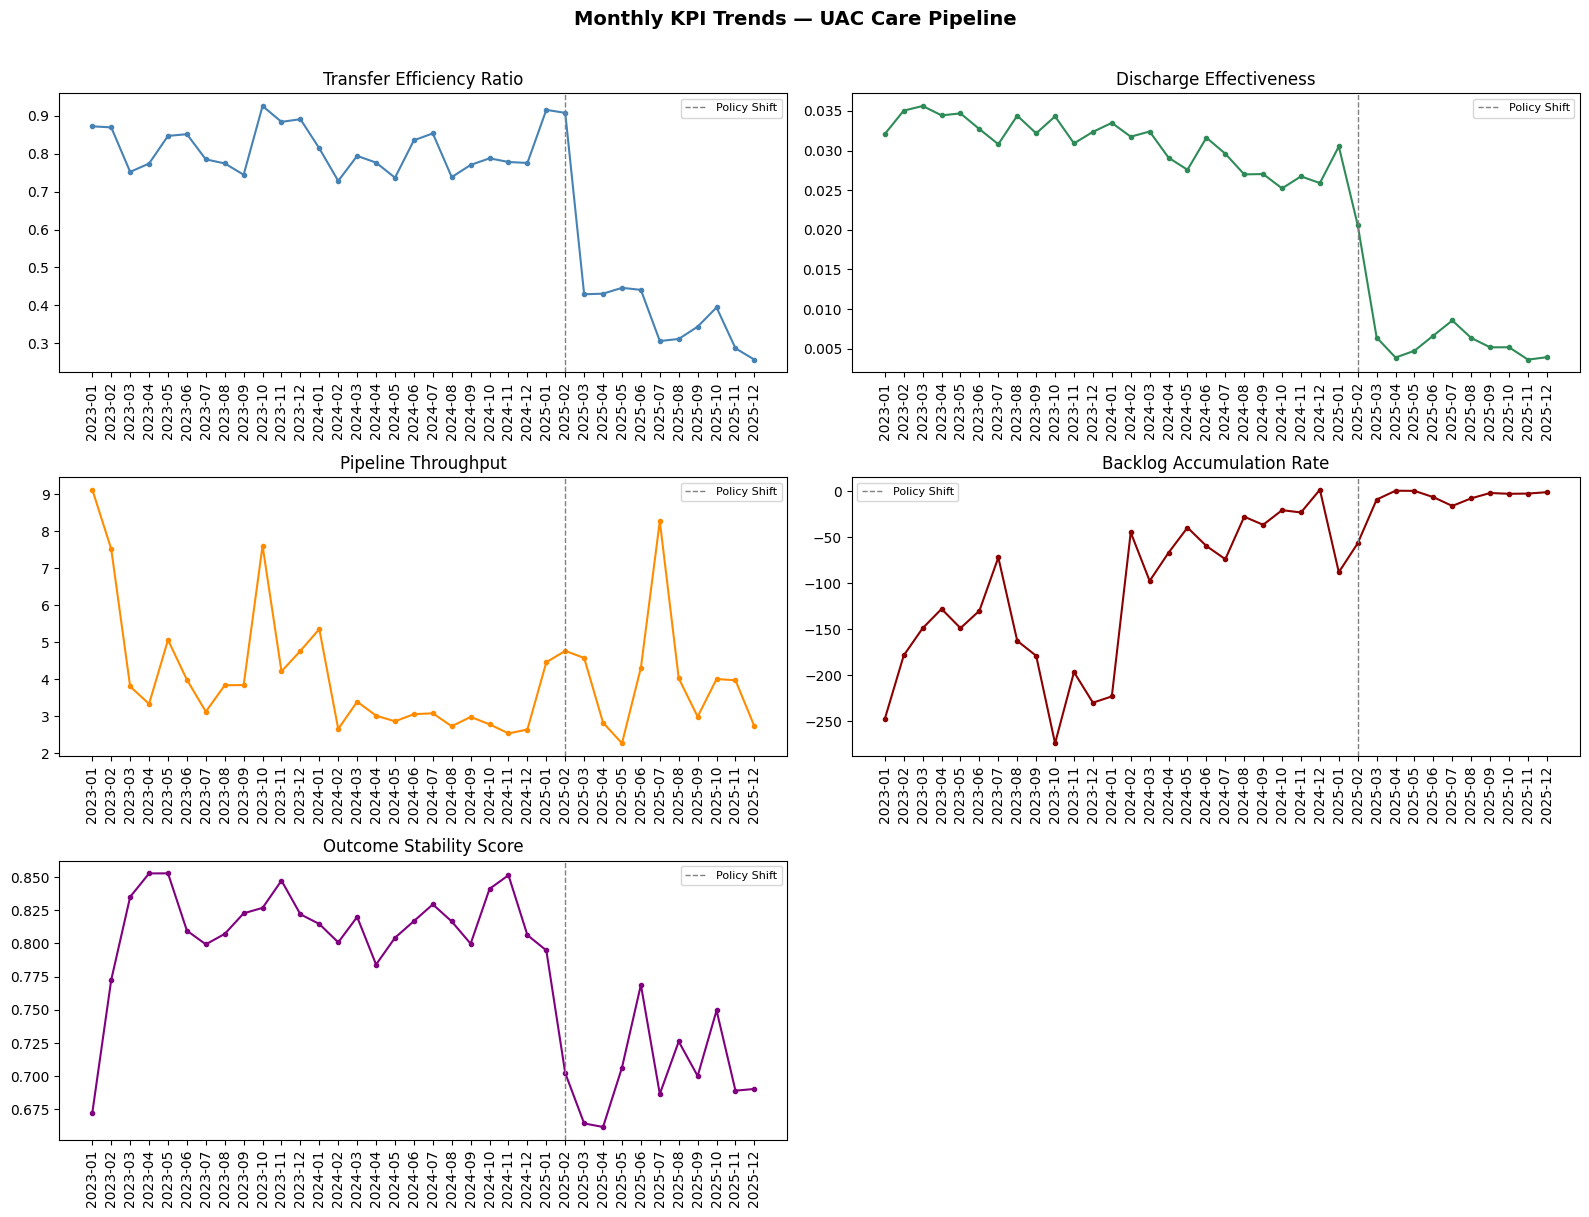

In [22]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

kpi_cols = ['avg_transfer_efficiency', 'avg_discharge_effectiveness', 
            'avg_pipeline_throughput', 'avg_backlog_rate', 'avg_stability']
kpi_titles = ['Transfer Efficiency Ratio', 'Discharge Effectiveness', 
              'Pipeline Throughput', 'Backlog Accumulation Rate', 'Outcome Stability Score']
colors = ['steelblue', 'seagreen', 'darkorange', 'darkred', 'purple']

for i, (col, title, color) in enumerate(zip(kpi_cols, kpi_titles, colors)):
    ax = axes[i // 2, i % 2]
    ax.plot(monthly_kpis['month'], monthly_kpis[col], color=color, linewidth=1.5, marker='o', markersize=3)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=90)
    ax.axvline('2025-02', color='gray', linestyle='--', linewidth=1, label='Policy Shift')
    ax.legend(fontsize=8)

axes[2, 1].axis('off')
plt.suptitle('Monthly KPI Trends — UAC Care Pipeline', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(charts_dir, 'monthly_kpi_trends.png'), dpi=150, bbox_inches='tight')
plt.show()

In [23]:
import os

project_root = os.path.dirname(os.getcwd())
data_dir = os.path.join(project_root, 'data')
os.makedirs(data_dir, exist_ok=True)

df['month'] = df['month'].astype(str)
df.to_csv(os.path.join(data_dir, 'processed_uac_data.csv'), index=False)
monthly_kpis.to_csv(os.path.join(data_dir, 'monthly_kpis.csv'), index=False)

print("Saved to:", data_dir)
print("Files created:", os.listdir(data_dir))
print("Final df shape:", df.shape)
print("Columns:", df.columns.tolist())

Saved to: C:\Users\Nikhil\OneDrive\Desktop\Care_Transition_Analytics\data
Files created: ['monthly_kpis.csv', 'processed_uac_data.csv']
Final df shape: (720, 23)
Columns: ['date', 'cbp_apprehended', 'cbp_custody', 'cbp_transferred_out', 'hhs_care', 'hhs_discharged', 'date_diff', 'transfer_efficiency_ratio', 'discharge_effectiveness', 'total_exits', 'total_entries', 'pipeline_throughput', 'month', 'regime', 'net_flow', 'cumulative_backlog', 'backlog_accumulation_rate', 'outcome_stability_score', 'outcome_stability_score_inverted', 'day_of_week', 'is_weekend', 'is_backlog_day', 'streak_id']
